# Photometry of M16
## Section 1: Importing Modules and Libraries

In [23]:
#import packages 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
import astropy.units as u
import urllib.request
import os
import gzip
import shutil
from astropy.io import fits


## Section 2: Downloading the FITS Image of M16

In [24]:
from astropy.utils.data import download_file

m16_url = "https://mast.stsci.edu/api/v0.1/Download/file/?uri=mast:HST/product/idnm29ytq_drz.fits" #URL of M16 image from the MAST Archive 
m16_file = download_file(m16_url, cache = True)
m16_file 
#"https://opencomputinglab.github.io/SubjectMatterNotebooks/astronomy/fits-images.html"

'C:\\Users\\ithea\\.astropy\\cache\\download\\url\\f8cf98df576c56953cbeb544353cc99a\\contents'

In [25]:
m16_hdu_list = fits.open(m16_file) 
if 'm16.fits' not in os.listdir():
    m16_hdu_list.writeto('m16.fits')

m16_data = fits.getdata('m16.fits')



## Section 3: Photometry Class Implementation
### In this section, we create a class to check the download status of the FITS file, display the image, and display the PSF model and radial profile of each star in the image.

In [26]:
%matplotlib widget
import numpy as np
from astropy.nddata.utils import Cutout2D
from scipy.optimize import curve_fit
from astropy.stats import sigma_clipped_stats 
import photutils
from photutils.detection import DAOStarFinder

class ClusterAnalyzer:
    """
    A class to perform PSF photometry on an astronomical image 
    of an open cluster.
    """
    
    def __init__(self, filename, fitsname, hdulist):
        """Initialize the object by loading the data."""
        self.filename = filename # name of the file that stores the fits data 
        self.fitsname = fitsname # fits data
        self.hdu_list = fits.open(self.filename) # fits header data 
        if 'self.fitsname' not in os.listdir():
            self.hdu_list.writeto('self.fitsname')
  
        
    
        
    def show_image(self, fitsname, filename, title="Open Cluster Field"):
        """Utility method to visualize the data."""
        self.filename = filename
        self.fitsname = fitsname
        if os.path.exists(filename) and fitsname is not None:
            from astropy.visualization import ZScaleInterval, AsinhStretch, ImageNormalize
    
    # Combine interval (ZScale finds optimal min/max) with stretch (AsinhStretch compresses dynamic range)
            norm = ImageNormalize(fitsname, 
                          interval=ZScaleInterval(),
                          stretch=AsinhStretch())
    
    # Calculate figure size maintaining aspect ratio
            aspect_ratio = fitsname.shape[0] / fitsname.shape[1]
            fig_width = 8
            fig_height = fig_width * aspect_ratio
    
            plt.figure(figsize=(fig_width, fig_height))
    
    # origin='lower' puts (0,0) at bottom-left (astronomical convention)
            plt.imshow(self.fitsname, cmap='gray', origin='lower', norm= norm)
            plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
            plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
              fontsize=14, fontweight='bold')
            plt.xlabel('X pixel', fontsize=12)
            plt.ylabel('Y pixel', fontsize=12)
            plt.tight_layout()
            plt.show()
        
        elif os.path.exists(filename):
            print("Skipping visualization - no image data loaded")
    
    def detect_star(self, fitsname):
        self.fitsname = fitsname 
        mean,median,std=sigma_clipped_stats(self.fitsname, sigma=3.0) #ignore outliers and NaNs
        print(mean,median,std)

        #Calculate figure size maintaining aspect ratio
        aspect_ratio = fitsname.shape [0]/fitsname.shape[1]
        fig_width = 8
        fig_height = fig_width * aspect_ratio
        daofind=DAOStarFinder(fwhm=3.0,threshold=5*std) #locating stars from fits data, searches images for local density maxima that have a peak amplitude greater than threshold (approximately; threshold is applied to a convolved image) and have a size and shape similar to the defined 2D Gaussian kernel (eveything is already fit)
       
        # Combine interval (ZScale finds optimal min/max) with stretch (AsinhStretch compresses dynamic range)
        norm = ImageNormalize(fitsname, 
                        interval=ZScaleInterval(),
                        stretch=AsinhStretch())
        
        # find sources
        sources=daofind(self.fitsname-median)
        display(sources)

        from photutils.aperture import CircularAperture #code from DESI ASTRO 
        positions = np.transpose((sources['xcentroid'],sources['ycentroid']))
        plt.figure(figsize=(fig_width, fig_height))
        apertures=CircularAperture(positions,r=10) #apertures around each star in cluster 
        apertures.plot(color='red',lw=2)

        plt.imshow(self.fitsname, cmap='gray', origin='lower', norm=norm)
        plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
        plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
            fontsize=14, fontweight='bold')
        plt.xlabel('X pixel', fontsize=12)
        plt.ylabel('Y pixel', fontsize=12)
        plt.tight_layout()
        plt.show()

            
    def fit_star_psf(self, fitsname, x_pos, y_pos, size):
        fig, axs = plt.subplots(2, figsize = (5,10))
        self.fitsname = fitsname
        self.x_pos = x_pos # star x position
        self.y_pos = y_pos # star y position
        self.size = size
         
        #Calculate figure size maintaining aspect ratio
        aspect_ratio = fitsname.shape [0]/fitsname.shape[1]
        fig_width = 8
        fig_height = fig_width * aspect_ratio
        plt.figure(figsize=(fig_width, fig_height))
        sigma = 3.0 
        fwhm = 2.355 * sigma #width of gaussian fit 
        cutout=Cutout2D(self.fitsname.data, (self.x_pos,self.y_pos), self.size) #cutout portion of image using fitted position values from the table above 
        minim=np.nanpercentile(cutout.data, 50) #____________
        maxim=np.nanpercentile(cutout.data, 99.9) #______________________
        axs[0].imshow(cutout.data, origin='lower', cmap='gray', vmin=minim, vmax=maxim, norm='log') 
        axs[0].set_xlabel('X [15 pixels]')
        axs[0].set_ylabel('Y [15 pixels]')
        axs[0].set_title(f'Gaussian PSF for Star in M16 (FWHM = {fwhm:.1f} pixels)'), 
                  #fontsize=12, fontweight='bold')
        # errors with plt.colorbar
        plt.show()
#image display


        x = np.arange(self.size)
        y = np.arange(self.size)
        x_grid, y_grid = np.meshgrid(x, y)

# PSF parameters
        x0, y0 = self.size // 2, self.size // 2  # Center
        amplitude = 1000.0  # Peak height
        sigma = 3.0

        r_squared = (x_grid - x0)**2 + (y_grid - y0)**2

# 2D Gaussian PSF
        psf = amplitude * np.exp(-r_squared / (2 * sigma**2))

# Calculate FWHM
        fwhm = 2.355 * sigma
        radius = np.sqrt((x_grid - x0)**2 + (y_grid - y0)**2).flatten()
        intensity = psf.flatten()
        sort_idx = np.argsort(radius)

        axs[1].plot(radius[sort_idx], intensity[sort_idx], 'b-', lw=2, alpha=0.7)
        axs[1].set_xlabel('Radius [pixels]', fontsize=11)
        axs[1].set_ylabel('Intensity (log scale)', fontsize=11)
        axs[1].set_title('Radial Profile for Star in M16', fontsize=12, fontweight='bold')
        axs[1].set_yscale('log')
        axs[1].grid(True, alpha=0.3, which='both')
        axs[1].set_xlim(0, 25)

        plt.show()

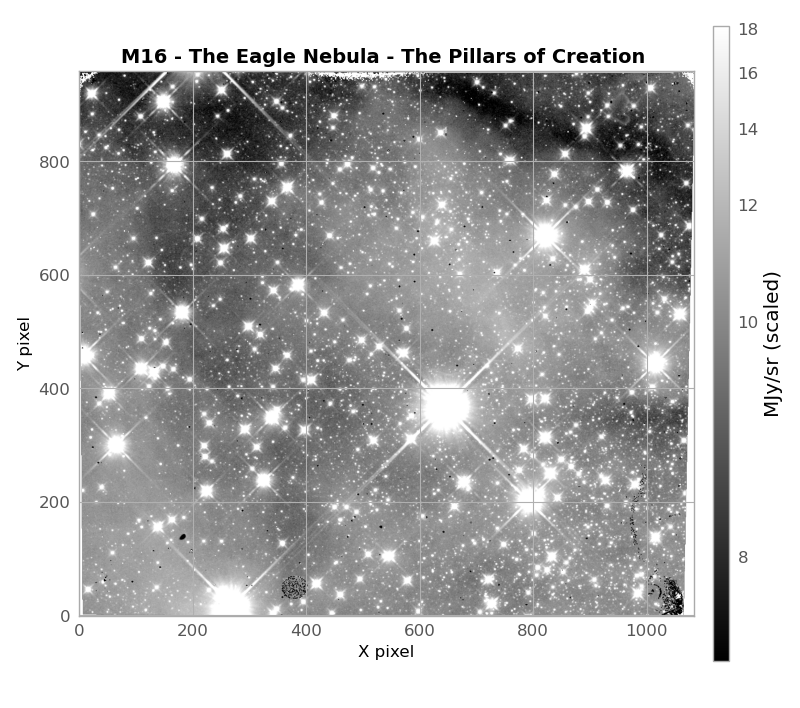

In [27]:
m16_image = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_image.show_image(m16_data, m16_file)

9.960842 9.955563 1.1637075


id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float32,float64,int64,float32,float32,float32,float64
1,513.9031613130381,0.24899927410070835,0.7134274434016479,0.73040944,0.645589082323234,25,6.990198,5.0858507,-1.7659091,-0.32525072576141817
2,1058.3574494395764,0.175306165478061,0.793750439339264,-0.34429437,-0.9255738663718497,25,220.13353,981.43805,-7.479657,-3.73258213369599
3,531.244923398953,0.7242084156717052,0.5570064105140807,-0.5596071,-0.4302496129471298,25,6.4244003,33.142887,-3.800976,-0.0630726861460992
4,593.1091554881418,0.9378723840545847,0.9975469012157493,-0.50010794,0.08692185662069553,25,14.901274,57.76857,-4.404229,-0.5700958578510678
5,640.3802391165789,1.507574418006386,0.6470048232320408,0.673943,0.12822422128700103,25,13.354204,69.563126,-4.6059475,-0.7253815941500346
6,795.2349149003131,1.280431992567023,0.5494838282636149,-0.5422639,-0.3843864627602948,25,11.553671,96.84379,-4.9651794,-0.5103941050557375
7,1022.472674043597,1.1740249867820212,0.5463697608690997,0.2001102,-0.24735685007746508,25,9.326599,30.36926,-3.7060857,-0.7250325849682359
8,1033.514583366267,-0.13493849847464445,0.3158235167294352,0.8184278,-0.545932829789004,25,0.6157017,-59.620502,nan,-0.11872204804076386
9,689.880822165965,2.1507383678415763,0.7034356503292205,-0.07083377,-0.06521381944696207,25,7.1584435,32.006096,-3.7630818,-0.038558766333971733


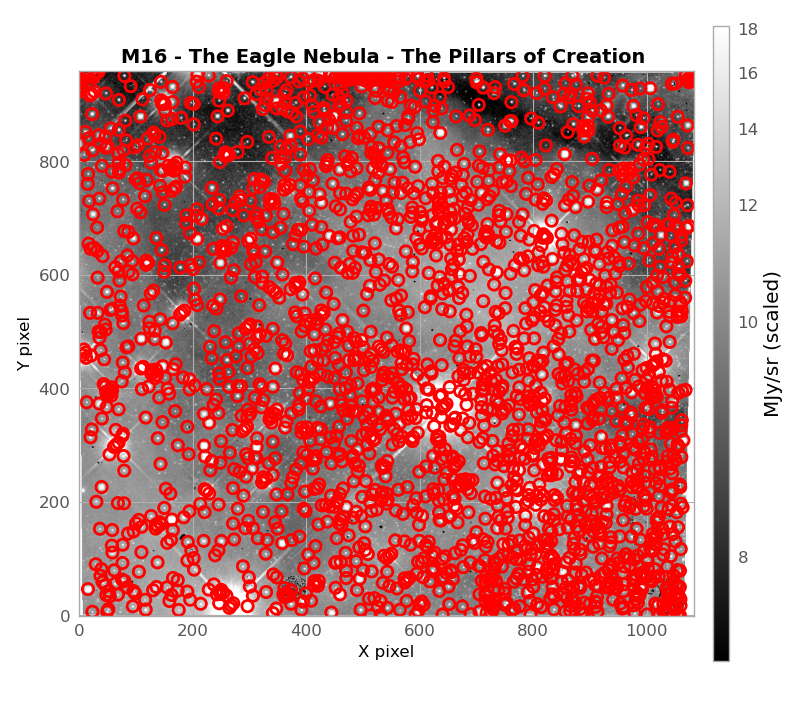

In [28]:
m16_star_positions = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_star_positions.detect_star(m16_data)

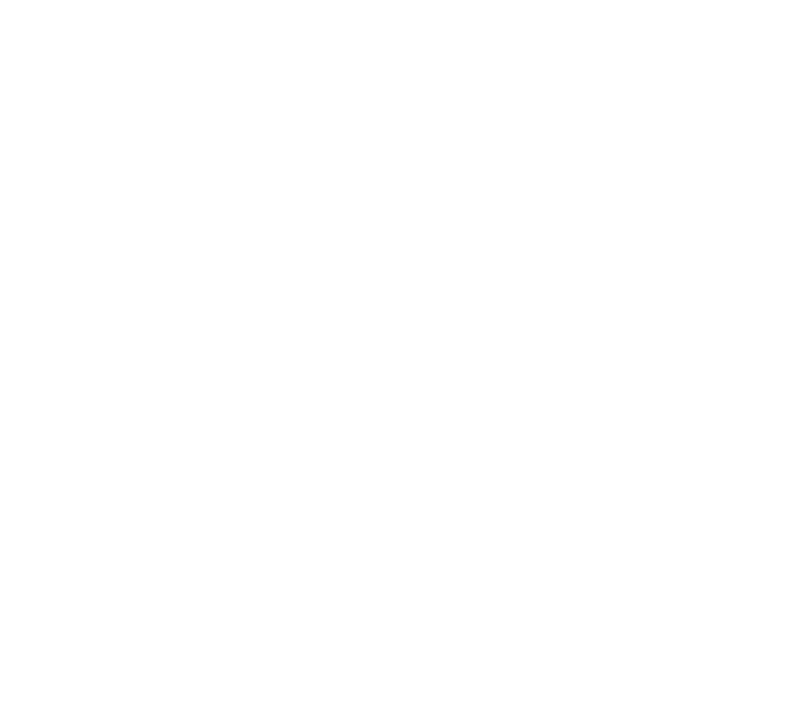

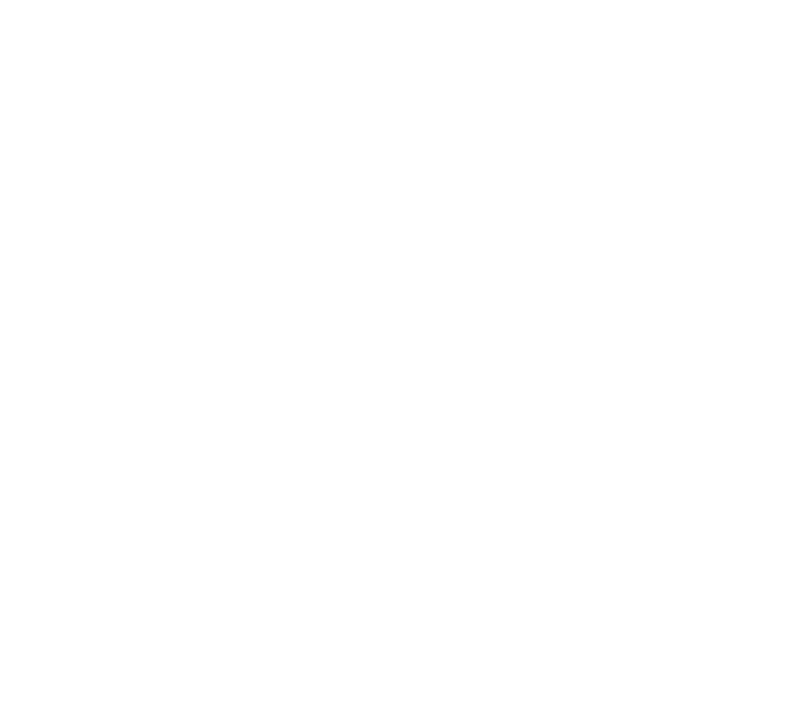

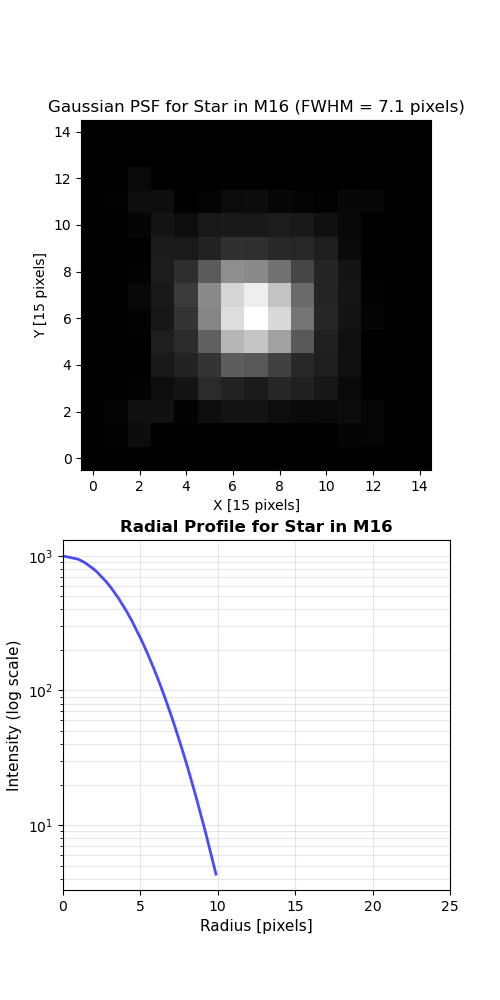

In [7]:
m16_cutout1 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout1.fit_star_psf(m16_data, 121.8, 621.6, 15)

### Star 2

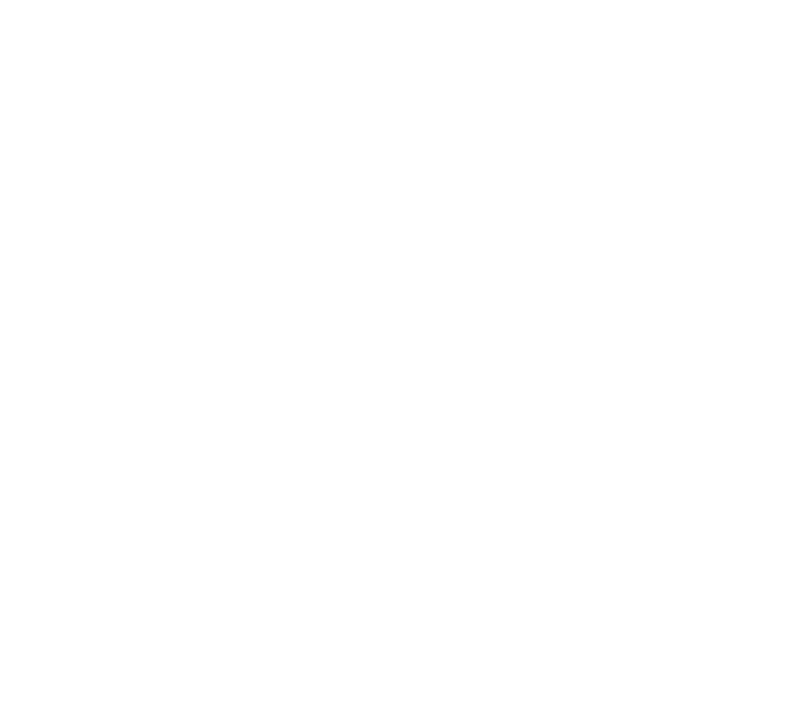

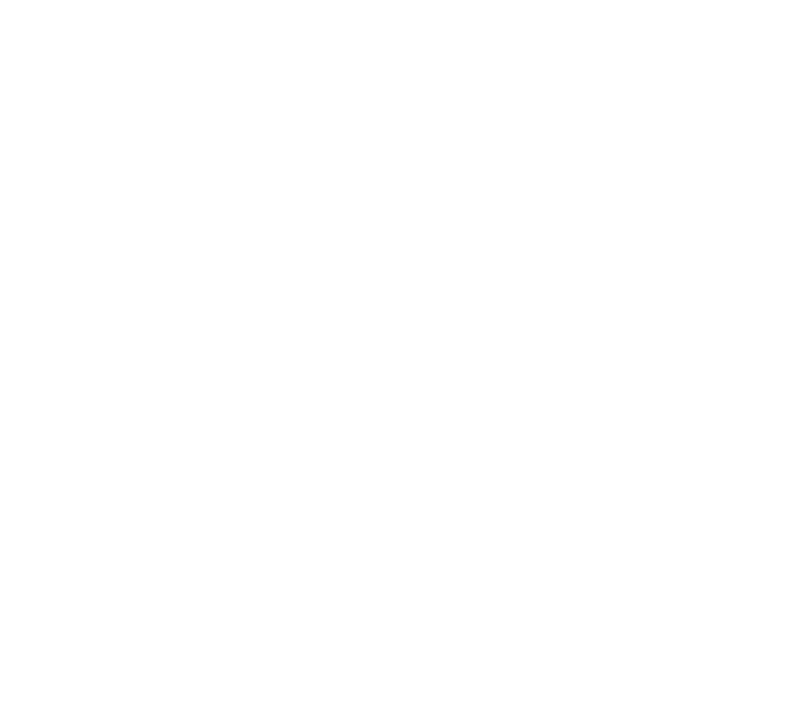

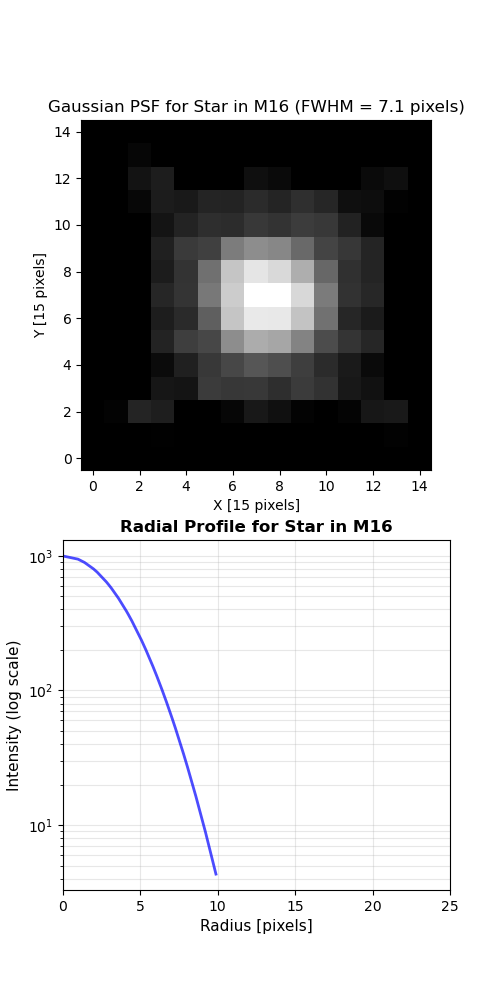

In [8]:
m16_cutout2 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout2.fit_star_psf(m16_data, 167.4, 793.5, 15)

### Star 3

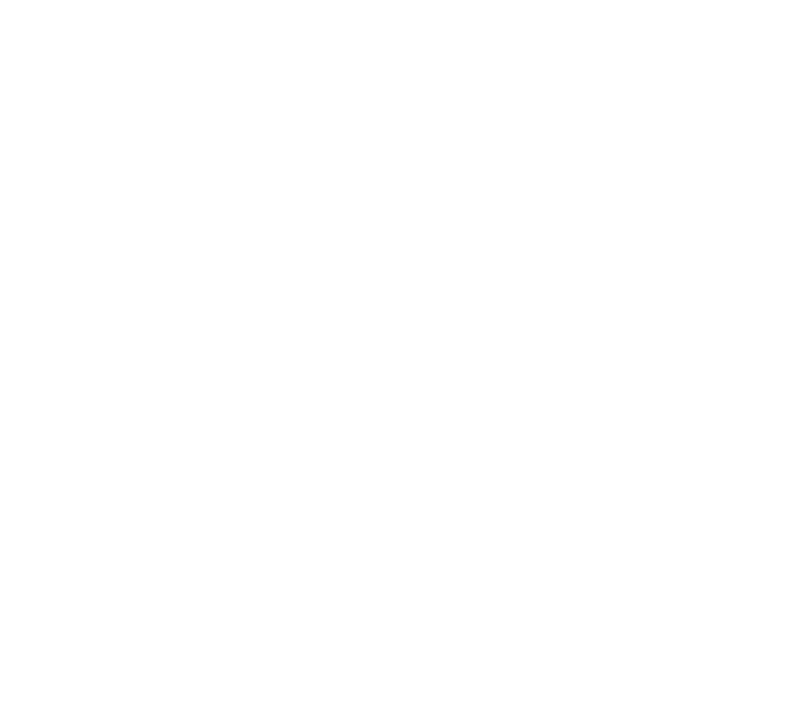

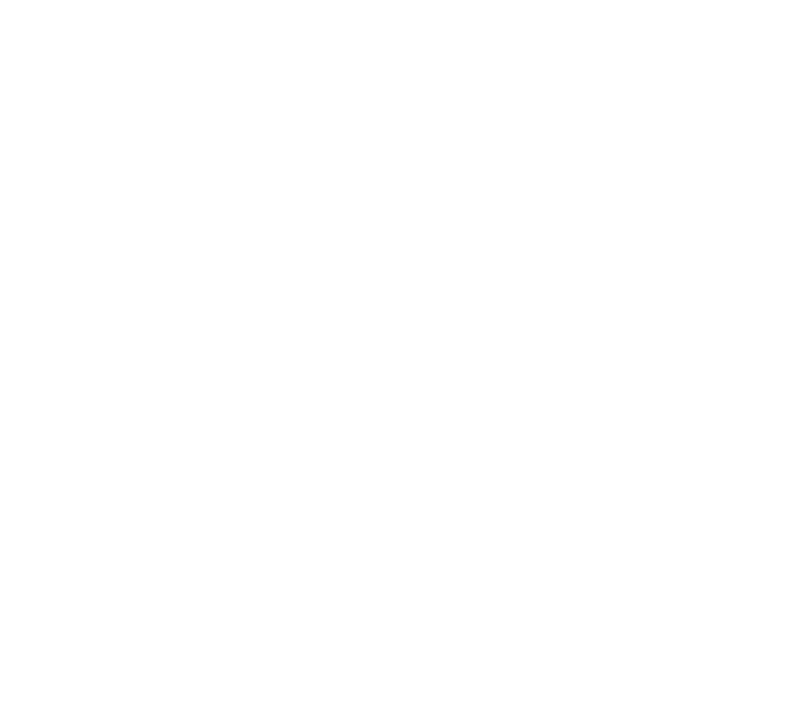

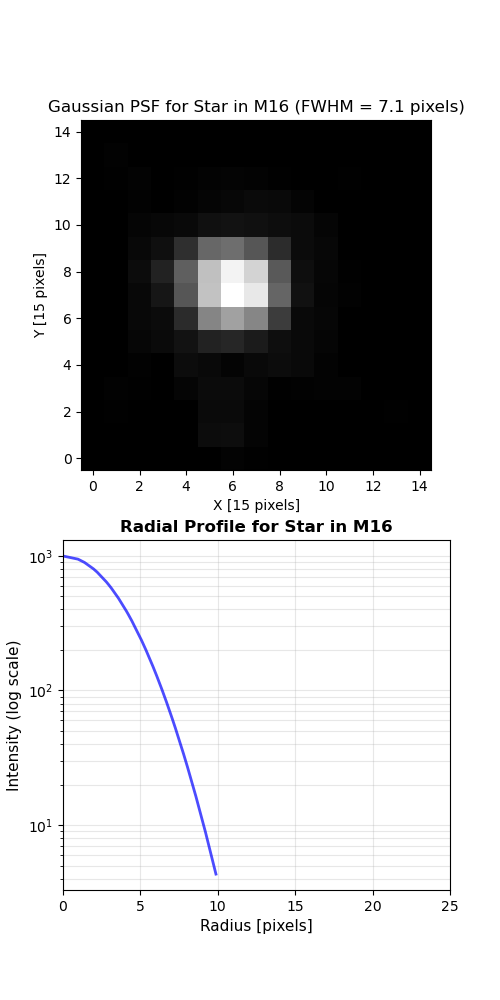

In [9]:
m16_cutout3 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout3.fit_star_psf(m16_data, 234.9, 753.4, 15)

### Star 4

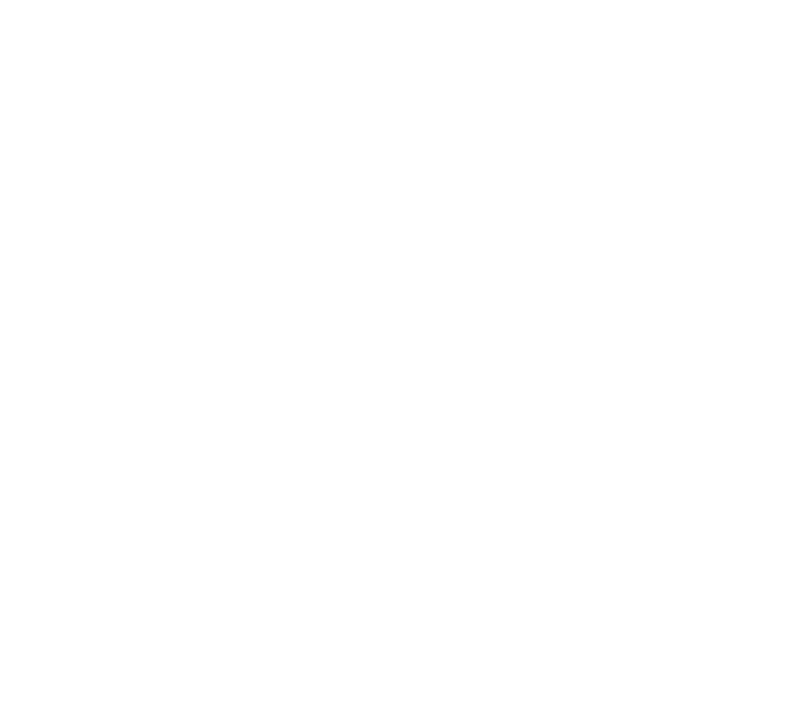

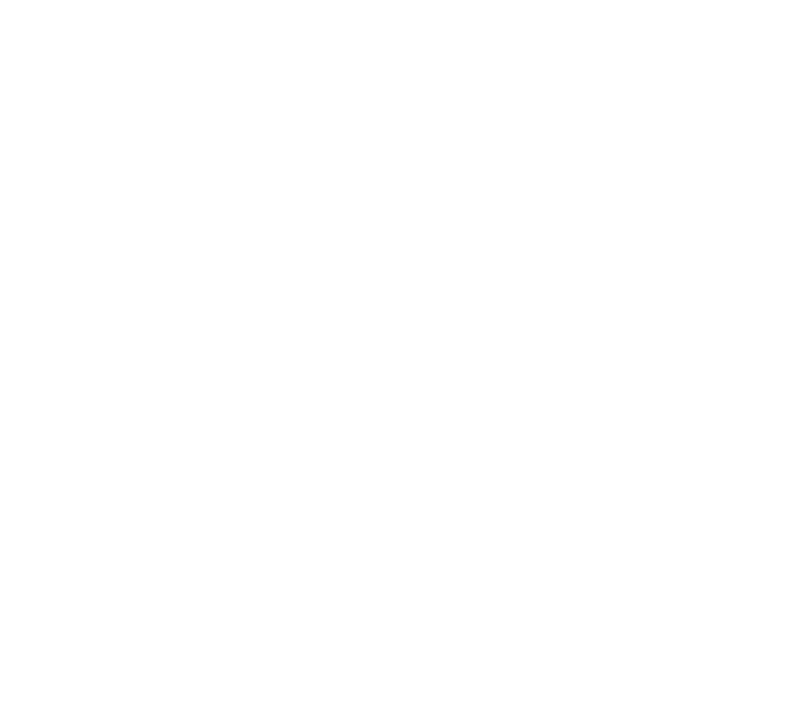

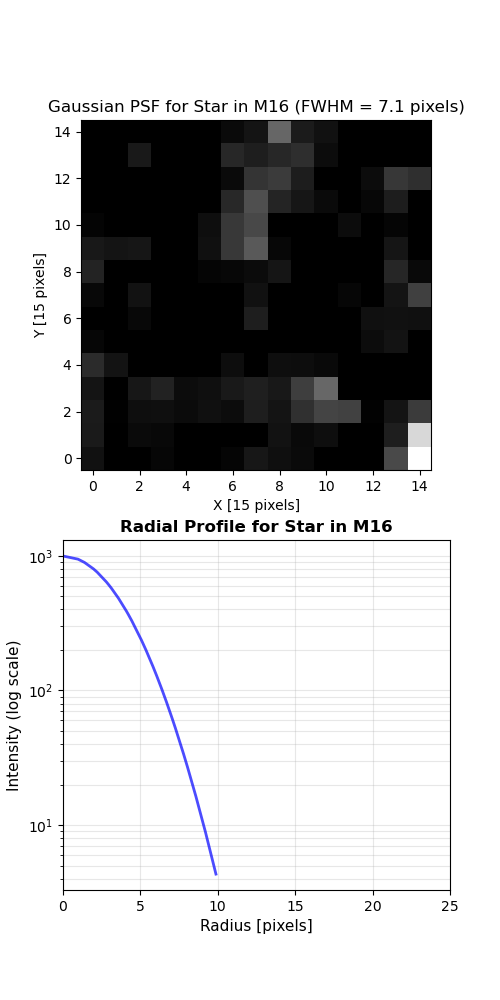

In [10]:
m16_cutout4 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout4.fit_star_psf(m16_data, 890.6, 764.4, 15)

### Star 5

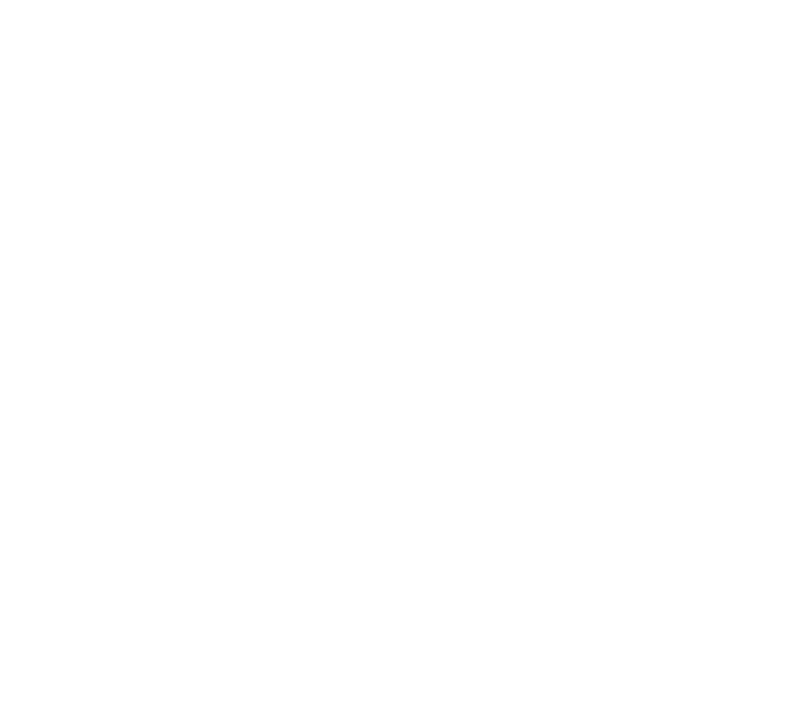

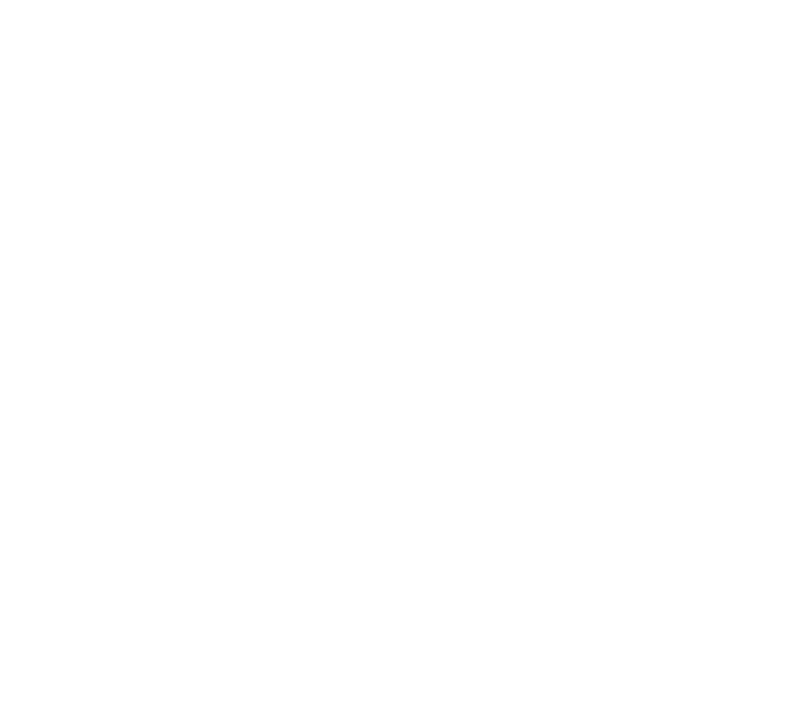

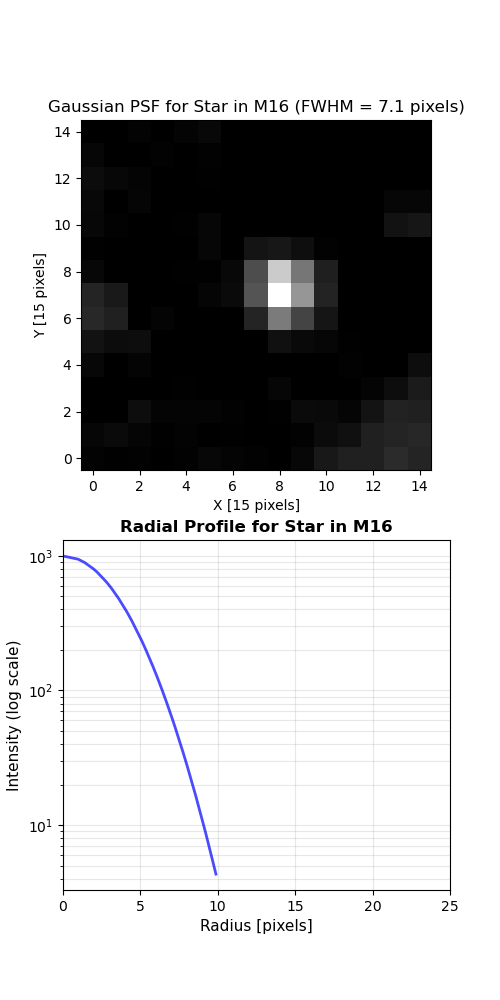

In [11]:
m16_cutout5 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout5.fit_star_psf(m16_data, 764.4, 501.1, 15)


### Star 6

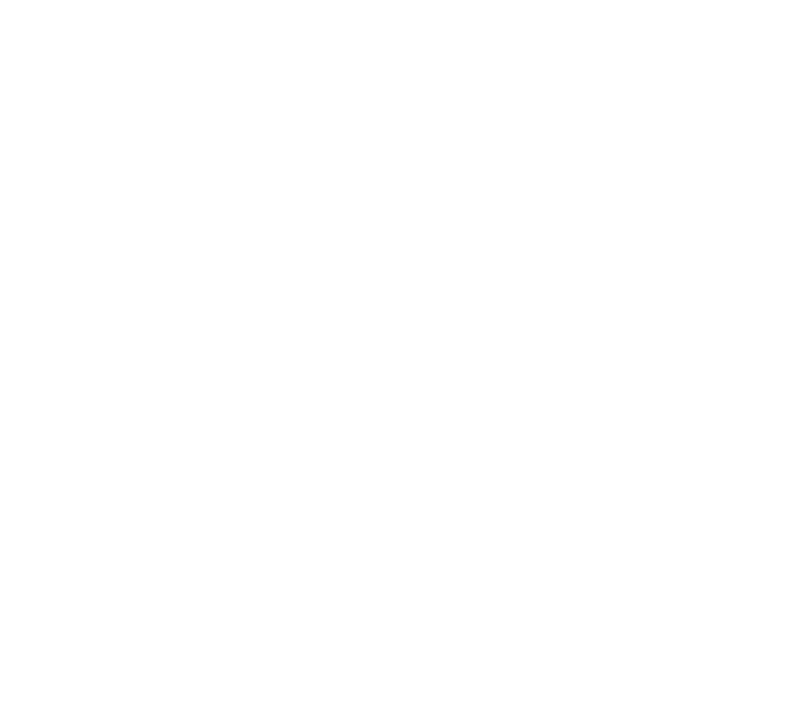

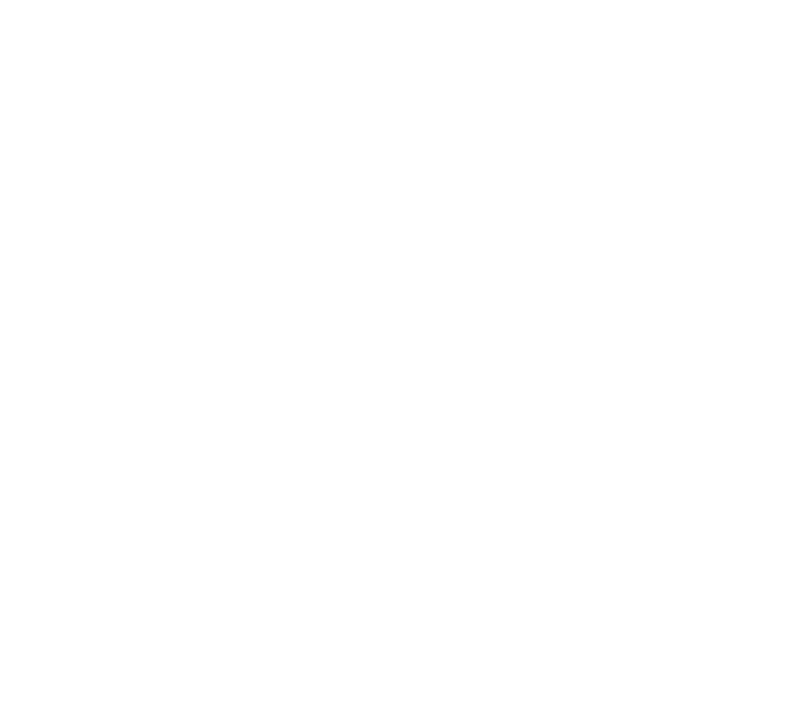

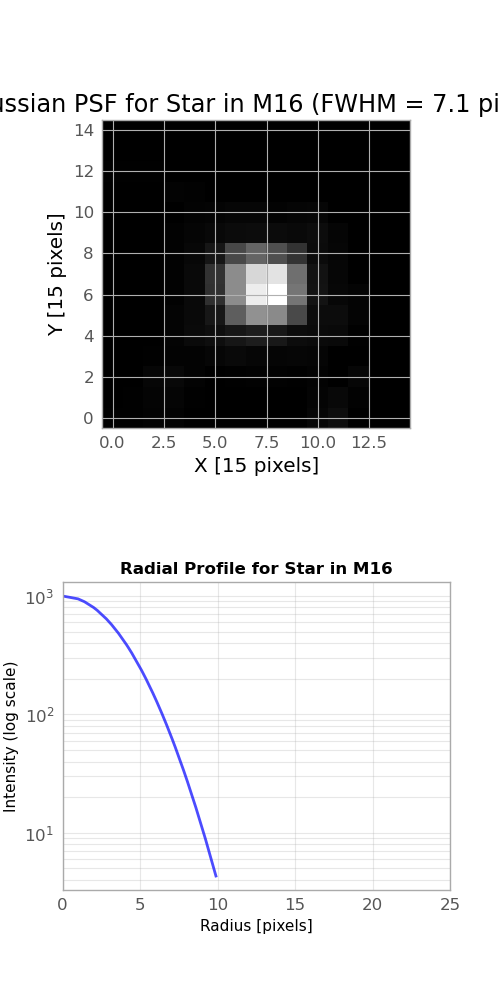

In [29]:
m16_cutout6 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout6.fit_star_psf(m16_data, 219, 132, 15)

### Star 7

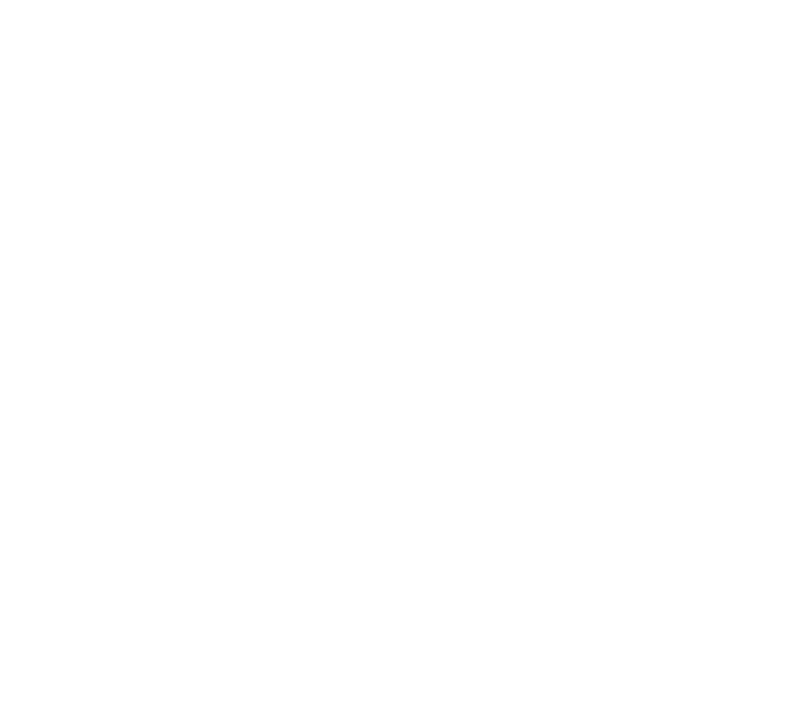

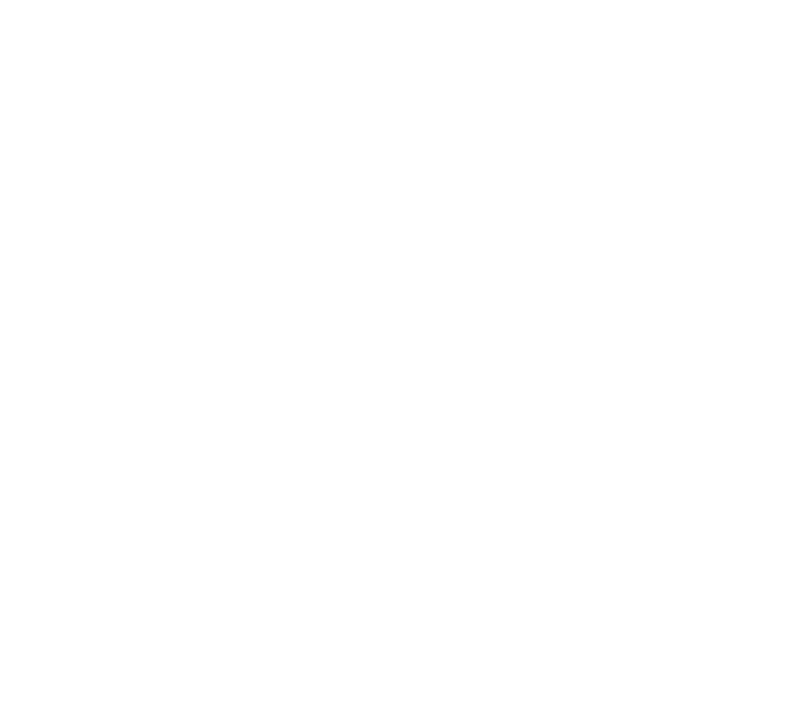

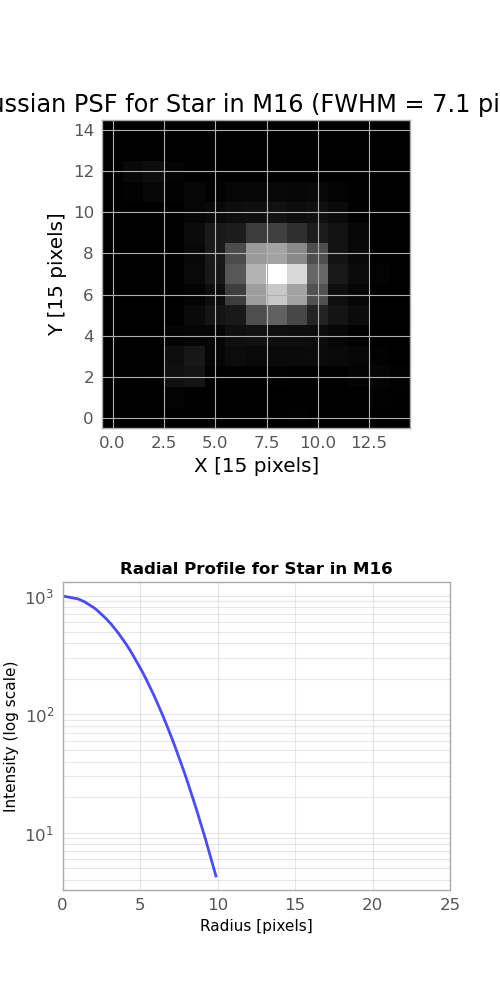

In [32]:
m16_cutout7 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout7.fit_star_psf(m16_data, 219, 355, 15)

### Star 8

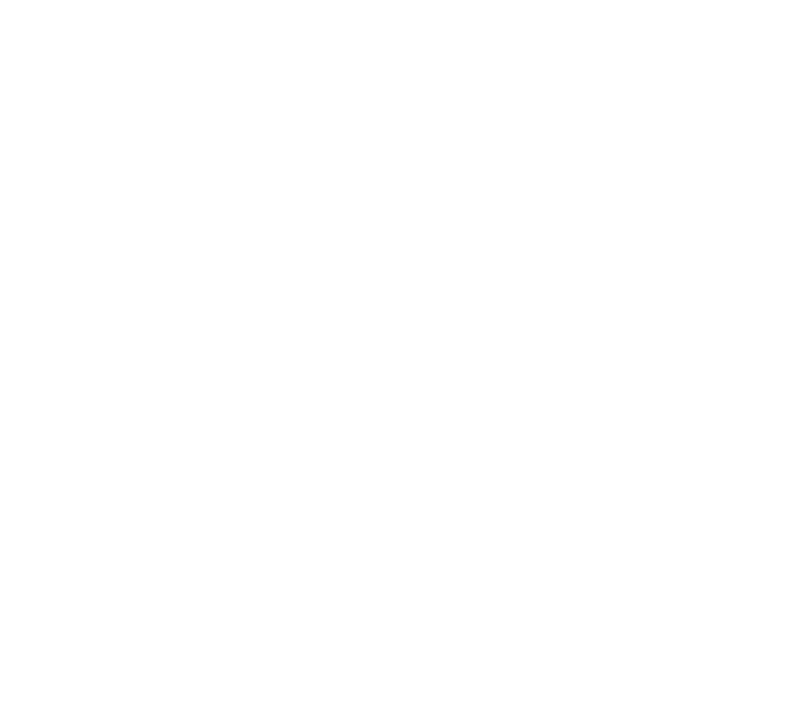

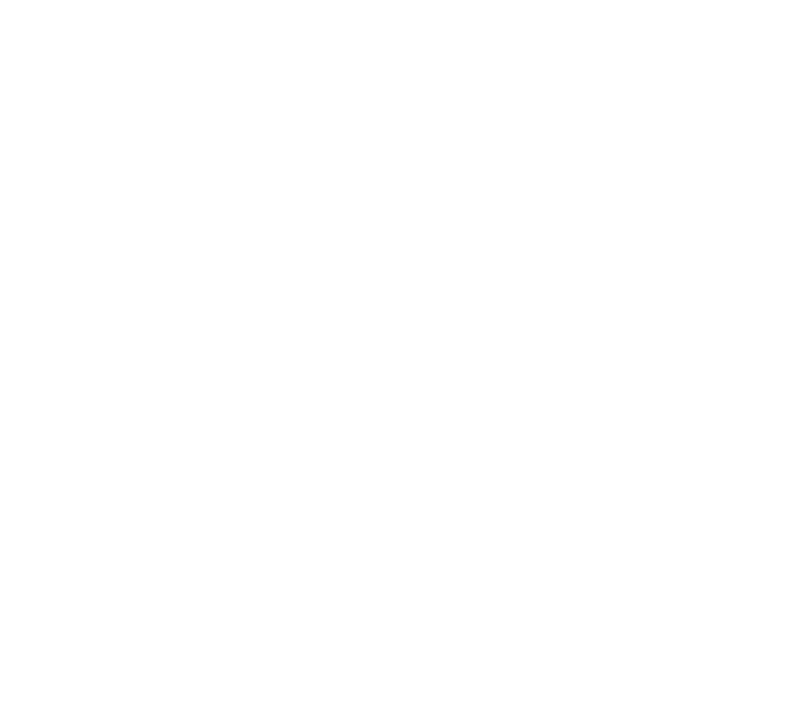

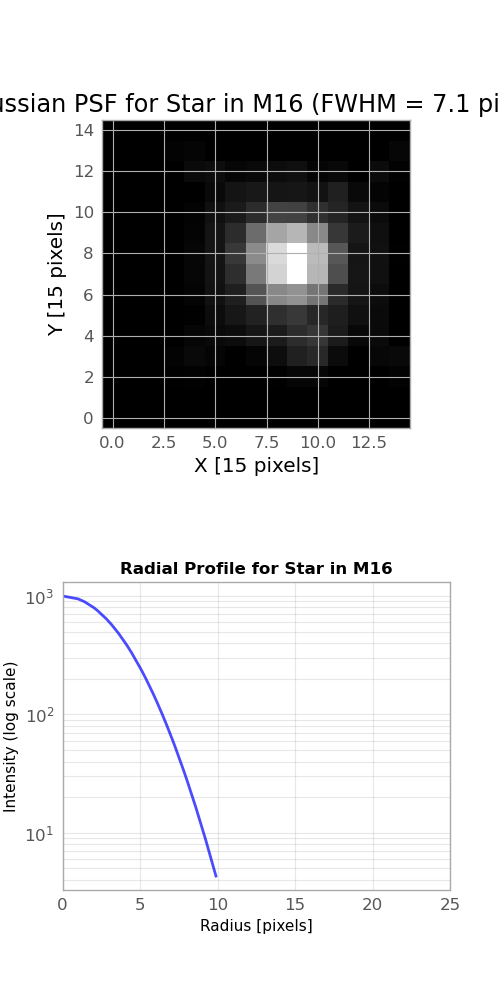

In [34]:
m16_cutout8 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout8.fit_star_psf(m16_data, 356, 127, 15)

### Star 9

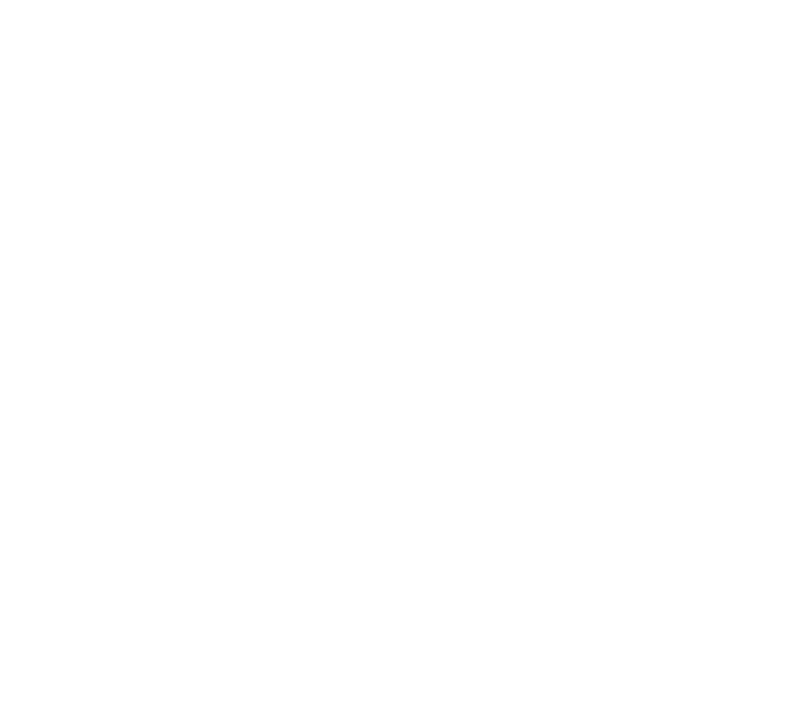

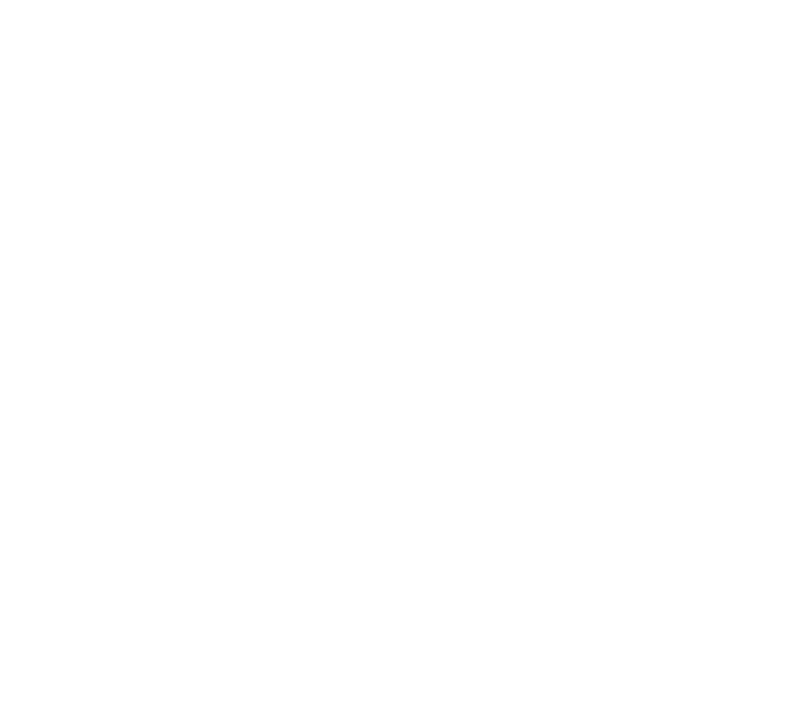

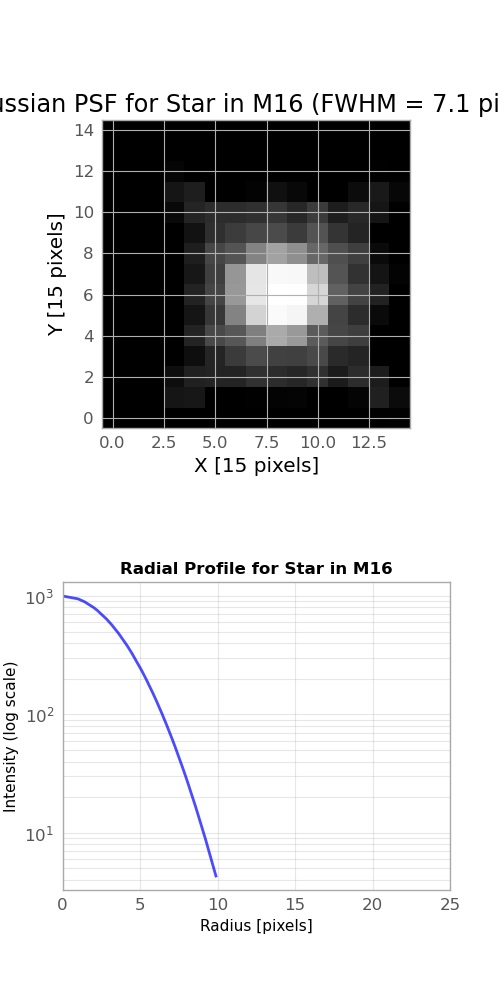

In [41]:
m16_cutout9 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout9.fit_star_psf(m16_data, 790, 203, 15)

### Star 10

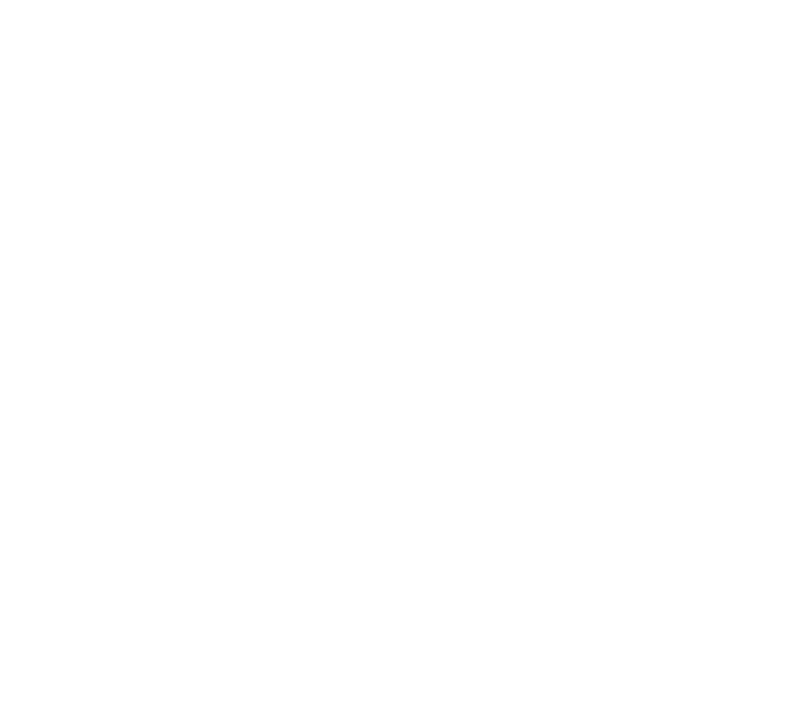

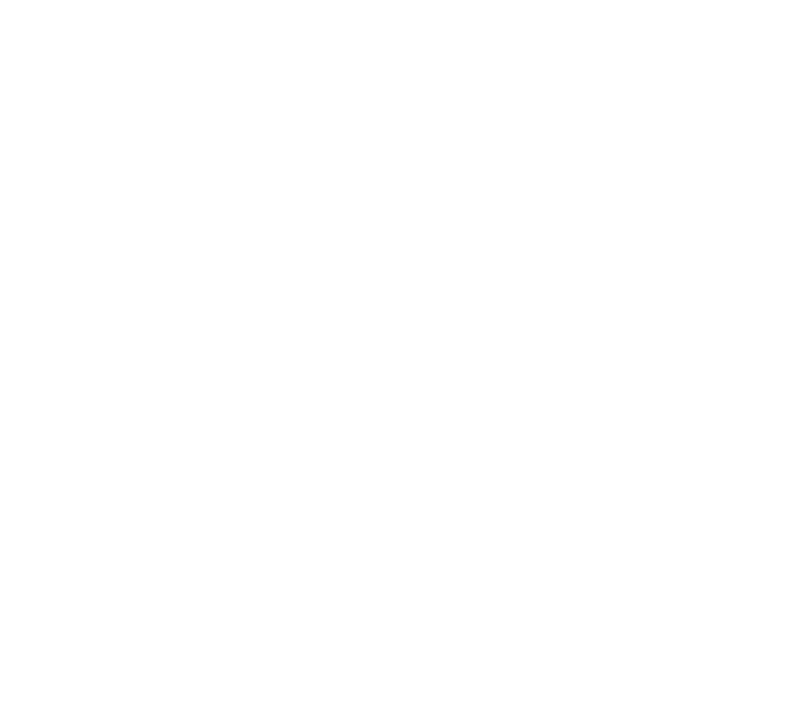

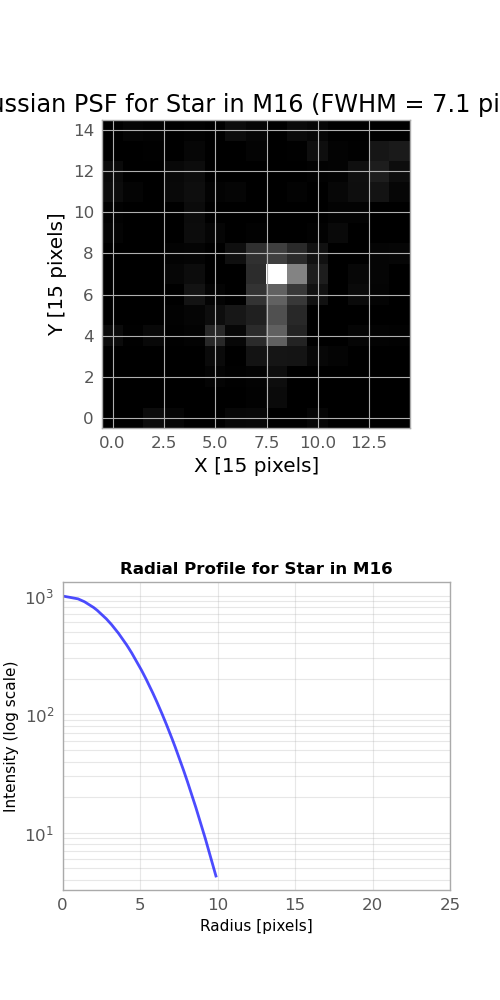

In [43]:
m16_cutout10 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout10.fit_star_psf(m16_data, 564, 10, 15)

## Color Magnitude Diagram

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from astroquery.mast import Observations
from astroquery.mast import Catalogs
import pandas as pd
import astropy.io.fits as fits

In [45]:
m16_hdu_list.info()

Filename: C:\Users\ithea\.astropy\cache\download\url\f8cf98df576c56953cbeb544353cc99a\contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     770   ()      
  1  SCI           1 ImageHDU        74   (1083, 959)   float32   
  2  WHT           1 ImageHDU        45   (1083, 959)   float32   
  3  CTX           1 ImageHDU        40   (1083, 959)   int32   
  4  HDRTAB        1 BinTableHDU    561   1R x 276C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, K, 6A, 4A, 1A, 4A, D, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, K, D, 3A, D, D, D, D, K, K, 8A, 23A, 11A, 19A, 4A, D, D, K, K, D, D, D, D, 23A, D, D, D, D, K, K, D, 3A, 8A, L, D, D, D, 23A, 1A, D, D, D, D, D, D, 12A, 12A, 8A, 23A, D, D, 10A, 10A, D, D, D, 2A, 23A, 3A, 4A, 8A, 7A, D, K, D, 6A, 9A, D, D, D, 4A, 18A, 3A, K, 5A, D, D, D, 8A, D, 3A, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, L, 1A, 4A, D, 3A, 6A, D, D, D, D, D, 23A, D, D, D, D, D, 1A, K, K, K, K, 8A, 23A, K, K, 10A, 

In [46]:

magnitudes = m16_hdu_list[1].data["PSFMAG"] #potential key for accessing magnitudes from HDU list
magnitudes = np.array(magnitudes)

# Creating arrays for g-band and r-band magnitudes
g_band = magnitudes[:, 1]
r_band = magnitudes[:, 2]

# Calculating color (g - r)
color_data1 = g_band - r_band

# Plotting the CMD
plt.figure(figsize=(8, 6))
plt.scatter(color_data1, r_band, s=3, color="black", label="M13 data")
plt.ylim(10, 30)
plt.gca().invert_yaxis()
plt.xlim(-2, 2)
plt.title("CMD of M16")
plt.ylabel("Apparent Magnitude (r-band)")
plt.xlabel("Color (g - r)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

# Code Blocks for Reference 

In [47]:
x=1550
y=400
position=(x,y)
star_1=star_cutout(x,y,position)

print(m16_hdu_list[0].header)

NameError: name 'star_cutout' is not defined

,xposition,yposition
0,121.8,621.8
1,167.4,793.5
2,234.9,753.4
3,890.6,609.2
4,764.4,501.1
5,219.0,132.0
6,219.0,355.0
7,356.0,158.0
8,790.0,203.0
9,564.0,10.0


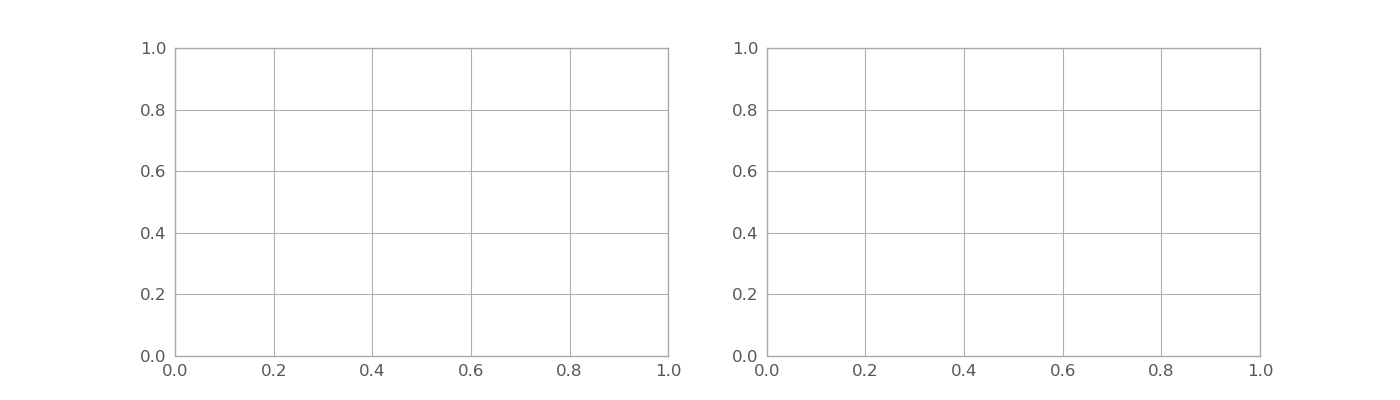

In [48]:
from astropy.nddata.utils import Cutout2D
pixels = 15 
size = (pixels,pixels)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sigma = 3.0
fwhm = 2.355 * sigma 

# PSF Fit of 2D image

#xposition_array = np.array([121.8, 167.4, 234.9, 890.6, 764.4]) #initally tried a 2D array
#yposition_array = np.array([621.8, 793.5, 753.4, 609.2, 501.1])
position_data = {"xposition": [121.8, 167.4, 234.9, 890.6, 764.4, 219, 219, 356, 790, 564], "yposition": [621.8, 793.5, 753.4, 609.2, 501.1, 132, 355, 158,203, 10]}
pos_df = pd.DataFrame.from_dict(position_data)
display(pos_df)
# Do we need cross-section through center?

#2D residuals data-psf model fit OR  radial profile / model  
# star 1- Cluseranalyszer(filename, x,y)
#star1.fitpsf()
#star1.showfit()

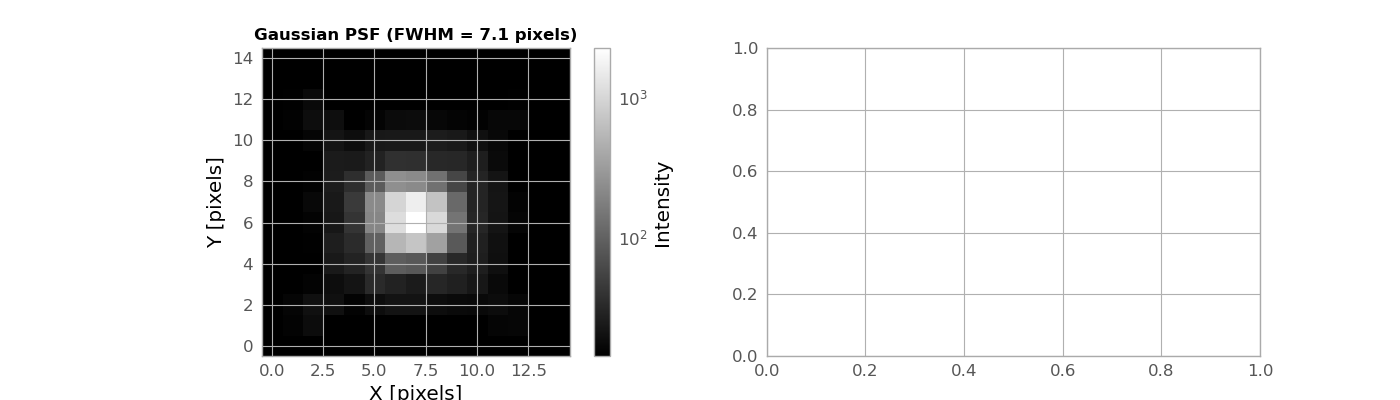

In [49]:
cutout=Cutout2D(m16_data.data, (121.8,621.6), size) #cutout portion of image using fitted position values from the table above 
minim=np.nanpercentile(cutout.data, 50) #____________
maxim=np.nanpercentile(cutout.data, 99.9) #______________________
im1 = axes[0].imshow(cutout.data, origin='lower', cmap='gray', vmin=minim, vmax=maxim, norm='log') #image display
axes[0].set_title(f'Gaussian PSF (FWHM = {fwhm:.1f} pixels)', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('X [pixels]')
axes[0].set_ylabel('Y [pixels]')
plt.colorbar(im1, ax=axes[0], label='Intensity')
plt.show()

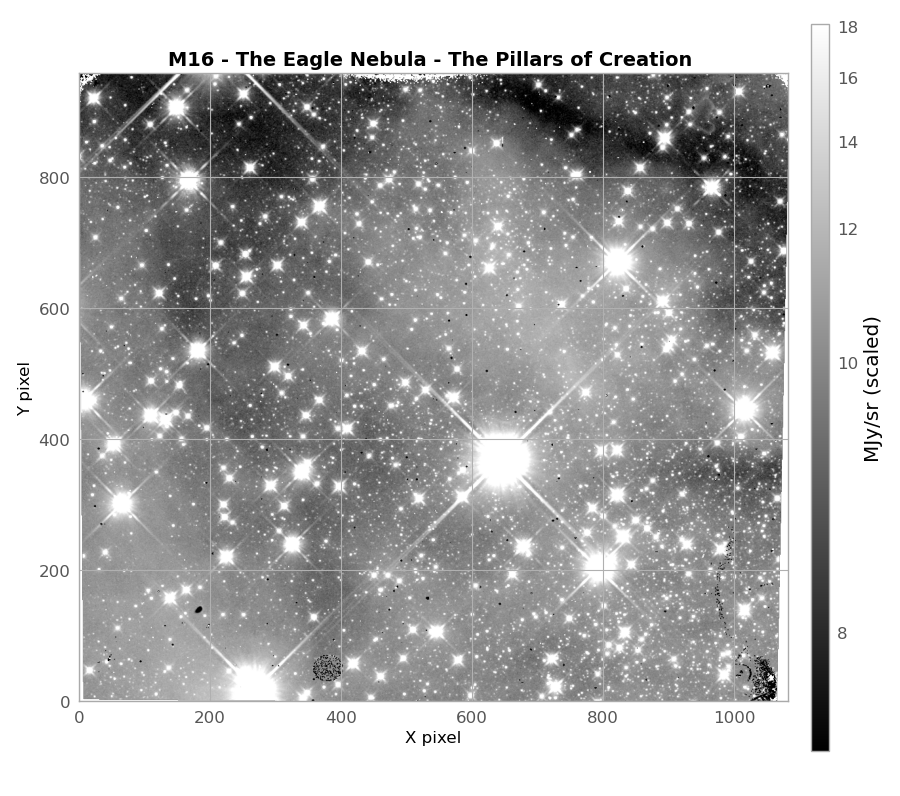

In [50]:
#Nice styling
from astropy.visualization import astropy_mpl_style
plt.style.use(astropy_mpl_style)


#Display the image
#plt.imshow(image_data, cmap='gray')
#plt.colorbar();
#Lecture 14
if os.path.exists(m16_file) and m16_data is not None:
    from astropy.visualization import ZScaleInterval, AsinhStretch, ImageNormalize
    
    # Combine interval (ZScale finds optimal min/max) with stretch (AsinhStretch compresses dynamic range)
    norm = ImageNormalize(m16_data, 
                          interval=ZScaleInterval(),
                          stretch=AsinhStretch())
    
    # Calculate figure size maintaining aspect ratio
    aspect_ratio = m16_data.shape[0] / m16_data.shape[1]
    fig_width = 9
    fig_height = fig_width * aspect_ratio
    
    plt.figure(figsize=(fig_width, fig_height))
    
    # origin='lower' puts (0,0) at bottom-left (astronomical convention)
    plt.imshow(m16_data, cmap='gray', origin='lower', norm=norm)
    plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
    plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
              fontsize=14, fontweight='bold')
    plt.xlabel('X pixel', fontsize=12)
    plt.ylabel('Y pixel', fontsize=12)
    plt.tight_layout()
    plt.show()
elif os.path.exists(m16_file):
    print("Skipping visualization - no image data loaded")

9.960842 9.955563 1.1637075


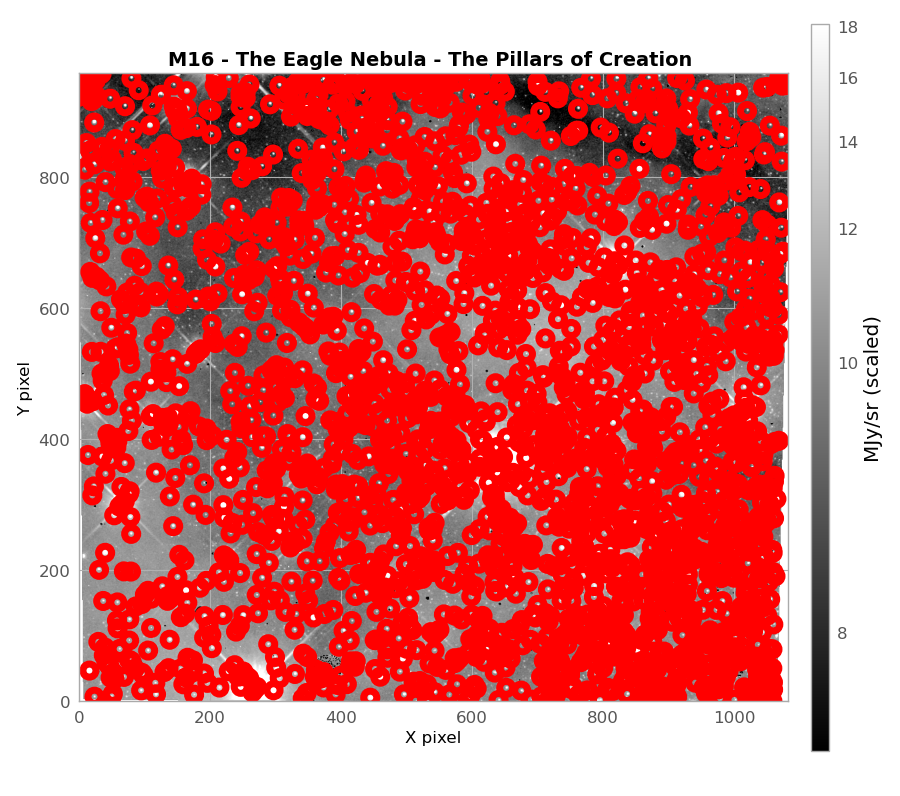

In [51]:
from astropy.stats import sigma_clipped_stats 
import photutils
from photutils.detection import DAOStarFinder
mean,median,std=sigma_clipped_stats(m16_data, sigma=3.0)
print(mean,median,std)

daofind=DAOStarFinder(fwhm=3.0,threshold=5*std)
# find sources
sources=daofind(m16_data-median)
sources

from photutils.aperture import CircularAperture #code from DESI ASTRO 
positions = np.transpose((sources['xcentroid'],sources['ycentroid']))
plt.figure(figsize=(fig_width, fig_height))
apertures=CircularAperture(positions,r=10)
apertures.plot(color='red',lw=5)

plt.imshow(m16_data, cmap='gray', origin='lower', norm=norm)
plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
            fontsize=14, fontweight='bold')
plt.xlabel('X pixel', fontsize=12)
plt.ylabel('Y pixel', fontsize=12)
plt.tight_layout()
plt.show()